230481E
PERERA K.W.A.O.V

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    breakpoints = sorted(breakpoints, key=lambda p: p[0])  # sort by x
    lut = np.zeros(256, dtype=np.float64)  # lookup table

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        if x1 == x0:
            continue
        xs = np.arange(x0, x1 + 1)
        ys = np.linspace(y0, y1, x1 - x0 + 1)  # linear interpolation
        lut[x0:x1 + 1] = ys

    lut = np.clip(lut, 0, 255).astype(np.uint8)
    transformed = cv2.LUT(im, lut)  # apply mapping
    return transformed, lut

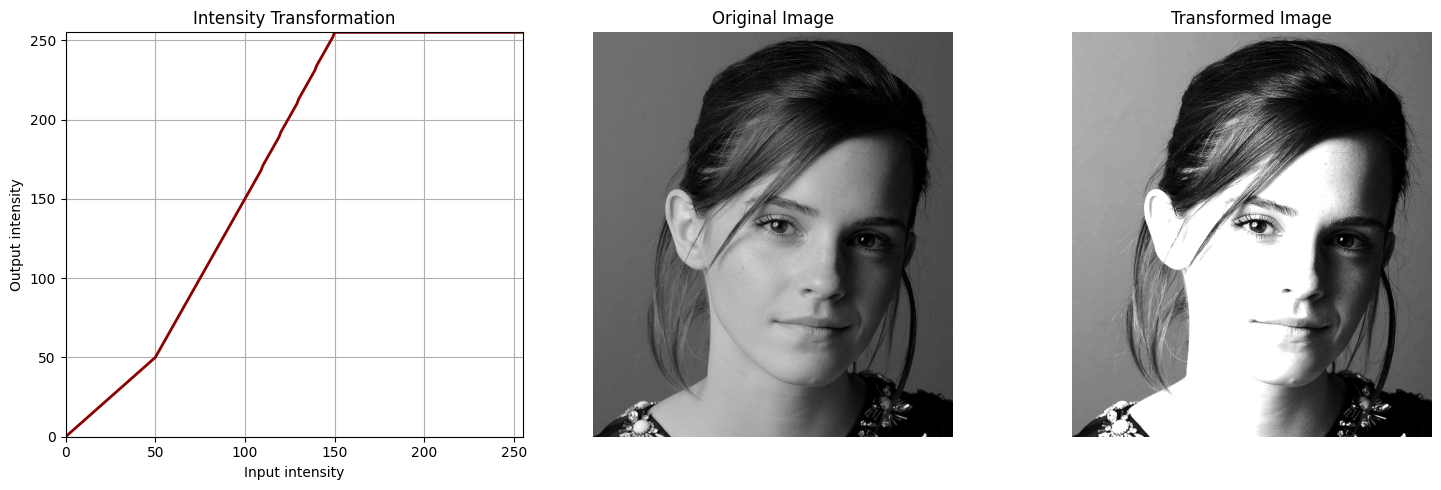

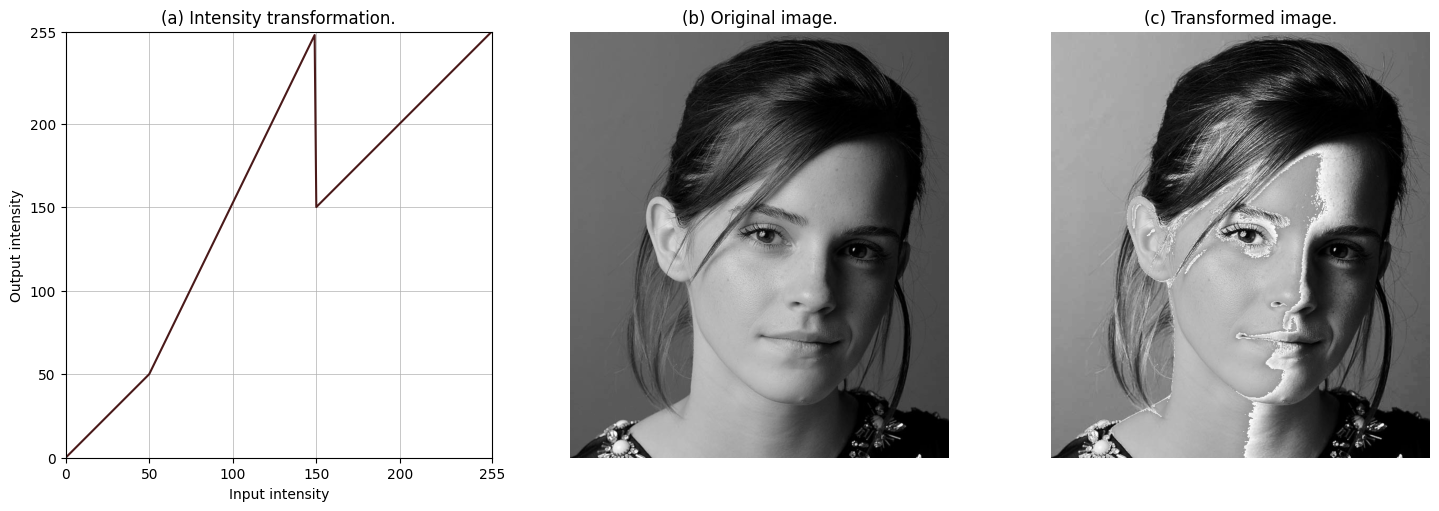

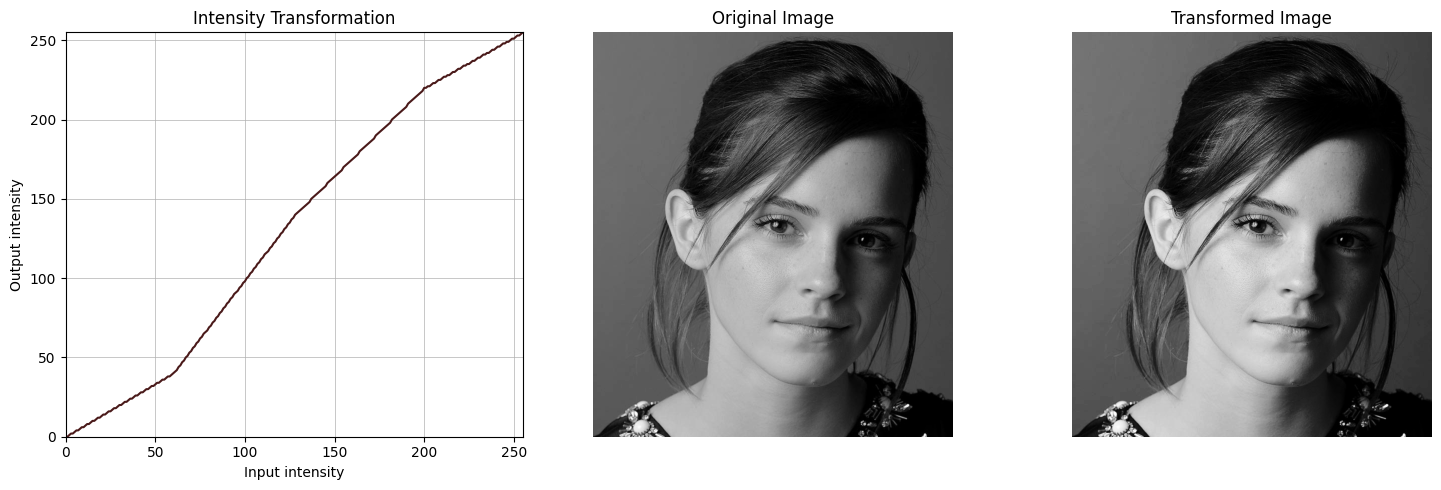

In [33]:
img = cv2.imread('images/images/q1.jpeg', cv2.IMREAD_GRAYSCALE)  # load the image in  grayscale

breakpoints = [
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
]  # transformation

transformed_img, lut = intensity_transform(img, breakpoints)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut, color='darkred', linewidth=2)  # transformation curve
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity Transformation')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True)

axes[1].imshow(img, cmap='gray')  # original
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(transformed_img, cmap='gray')  # after transform
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

breakpoints = [
    [0, 0],
    [50, 50],
    [150, 255],
    [150, 150],
    [255, 255]
] 

lut = np.zeros(256, dtype=np.float64)
for i in range(len(breakpoints) - 1):
    x0, y0 = breakpoints[i]
    x1, y1 = breakpoints[i + 1]
    if x1 == x0:
        continue
    xs = np.arange(x0, x1 + 1)
    ys = np.linspace(y0, y1, x1 - x0 + 1)
    lut[x0:x1 + 1] = ys

lut_uint8 = np.clip(lut, 0, 255).astype(np.uint8)
transformed_img = cv2.LUT(img, lut_uint8)  # apply to image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# transformation curve
axes[0].plot(np.arange(256), lut, color='#4a1a1a', linewidth=1.5)
ticks = [0, 50, 100, 150, 200, 255]
axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_aspect('equal')
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('(a) Intensity transformation.')
axes[0].grid(True, linewidth=0.5)

# original image
axes[1].imshow(img, cmap='gray')
axes[1].set_title('(b) Original image.')
axes[1].axis('off')

# transformed image
axes[2].imshow(transformed_img, cmap='gray')
axes[2].set_title('(c) Transformed image.')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Experimented Transform
breakpoints = [
    [0, 0],
    [60, 40],
    [128, 140],
    [200, 220],
    [255, 255]
]  # smooth S-curve

transformed_img, lut = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut, color='#4a1a1a', linewidth=1.5)  # transformation curve
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity Transformation')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True, linewidth=0.5)

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(transformed_img, cmap='gray')  # after transform
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()


Question 2


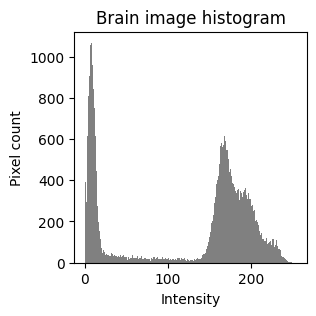

In [5]:
brain_img = cv2.imread('images/images/q2.jpeg', cv2.IMREAD_GRAYSCALE)  # load brain image
plt.figure(figsize=(3, 3))
plt.hist(brain_img.ravel(), bins=256, range=(0, 255), color='gray')  # intensity distribution
plt.xlabel('Intensity')
plt.ylabel('Pixel count')
plt.title('Brain image histogram')
plt.show()

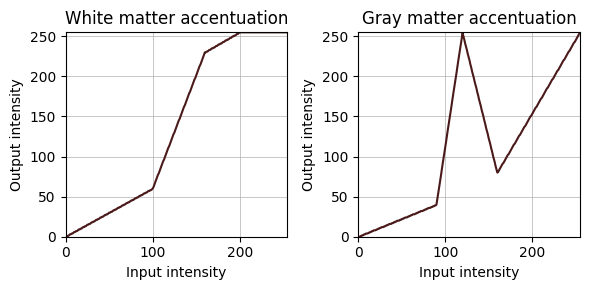

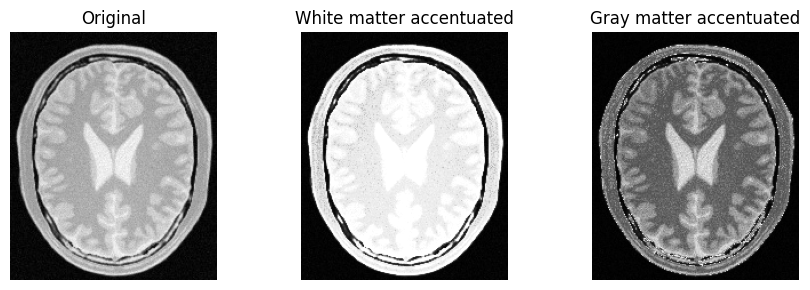

In [12]:
white_matter_bp = [
    [0, 0],
    [100, 60],
    [160, 230],   
    [200, 255],
    [255, 255]
]

white_matter_img, white_lut = intensity_transform(brain_img, white_matter_bp)
gray_matter_bp = [
    [0, 0],
    [90, 40],
    [120, 255],   
    [160, 80],
    [255, 255]
]

gray_matter_img, gray_lut = intensity_transform(brain_img, gray_matter_bp)
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].plot(np.arange(256), white_lut, color='#4a1a1a', linewidth=1.5)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('White matter accentuation')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True, linewidth=0.5)

axes[1].plot(np.arange(256), gray_lut, color='#4a1a1a', linewidth=1.5)
axes[1].set_xlabel('Input intensity')
axes[1].set_ylabel('Output intensity')
axes[1].set_title('Gray matter accentuation')
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(True, linewidth=0.5)

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(brain_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(white_matter_img, cmap='gray')
axes[1].set_title('White matter accentuated')
axes[1].axis('off')

axes[2].imshow(gray_matter_img, cmap='gray')
axes[2].set_title('Gray matter accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Question 3

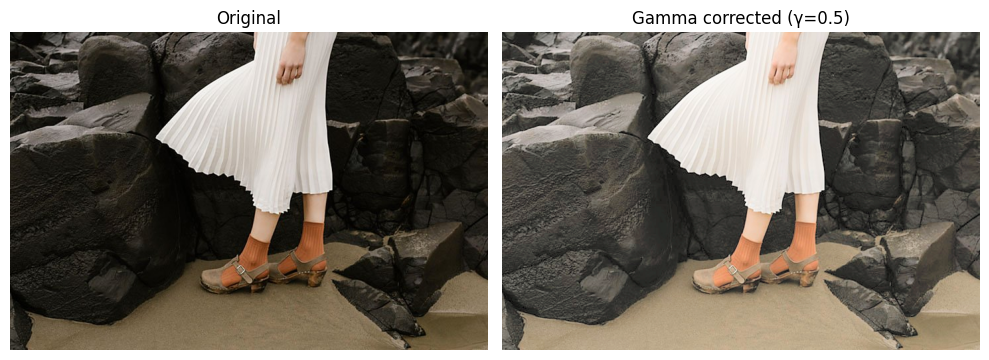

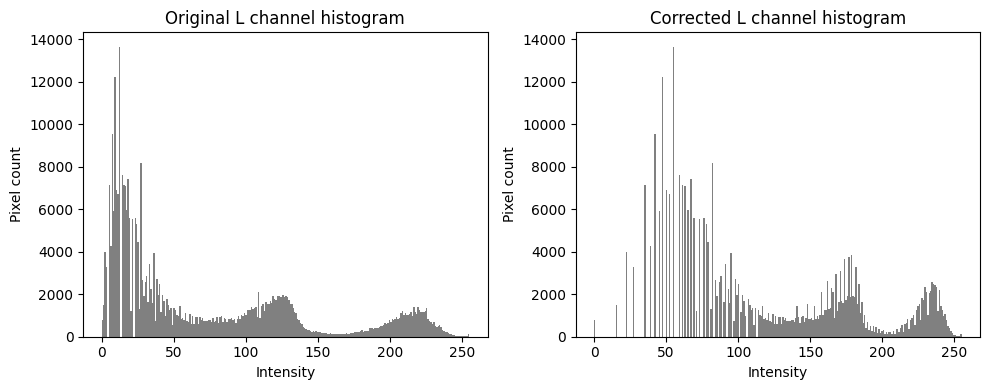

In [ ]:
img_gamma = cv2.imread('images/images/image for gamma correction.jpeg')  # BGR by default
img_gamma_rgb = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2RGB)  
lab = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2LAB)  # split into L, a, b
L, a, b = cv2.split(lab)

gamma = 0.5  # gamma value: <1 brightens, >1 darkens

L_norm = L / 255.0  # normalize to [0, 1]
L_corrected = np.power(L_norm, gamma)  # apply gamma
L_corrected = np.uint8(L_corrected * 255)

lab_corrected = cv2.merge([L_corrected, a, b]) 
img_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR) 
img_corrected_rgb = cv2.cvtColor(img_corrected, cv2.COLOR_BGR2RGB)  # display

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_gamma_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_corrected_rgb)
axes[1].set_title(f'Gamma corrected (γ={gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(L.ravel(), bins=256, range=(0, 255), color='gray')  # original L histogram
axes[0].set_title('Original L channel histogram')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Pixel count')

axes[1].hist(L_corrected.ravel(), bins=256, range=(0, 255), color='gray')  # corrected L histogram
axes[1].set_title('Corrected L channel histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()